# Kickstarter Campaign Success Prediction

## Business Problem

Crowdfunding platforms host thousands of campaigns every year, yet many fail to achieve their funding goals.

The objective of this project is to predict whether a Kickstarter campaign will be successful using only information available prior to launch. In addition to predictive modeling, the analysis aims to identify the factors most strongly associated with campaign success and generate actionable recommendations for campaign creators.

## Project Objectives

* Identify drivers of crowdfunding success
* Perform statistical hypothesis testing
* Engineer predictive campaign features
* Compare machine learning models
* Explain key factors influencing campaign outcomes


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv(r"C:\Users\austi\OneDrive\Documents\Data Science Projects\Kickstarter Success Prediction with Explainable AI\data\ks-projects-201801.csv")

df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


## Dataset Overview

The dataset contains Kickstarter crowdfunding campaigns across multiple industries including technology, music, games, publishing, film, and design.

After filtering to completed campaigns, the final modeling dataset contained 331,675 projects and was used to predict campaign success prior to launch.


## Data Quality Assessment

In [12]:
df.shape

(378661, 15)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


In [14]:
df.isnull().sum()

ID                     0
name                   4
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged         3797
usd_pledged_real       0
usd_goal_real          0
dtype: int64

In [15]:
df['state'].value_counts()

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

## Target Variable Creation

In [16]:
df = df[
    df["state"].isin(
        ["successful", "failed"]
    )
]

In [17]:
df["Success"] = (
    df["state"] == "successful"
).astype(int)

In [18]:
df["state"].value_counts()

state
failed        197719
successful    133956
Name: count, dtype: int64

In [19]:
df["Success"] = (
    df["state"] == "successful"
).astype(int)

df["Success"].value_counts(normalize=True)

Success
0    0.596123
1    0.403877
Name: proportion, dtype: float64

## Data Leakage Analysis

In [20]:
leakage_cols = [
    "state",
    "pledged",
    "backers",
    "usd pledged",
    "usd_pledged_real"
]

df = df.drop(columns=leakage_cols)

In [21]:
df["launched"] = pd.to_datetime(df["launched"])
df["deadline"] = pd.to_datetime(df["deadline"])

## Feature Engineering

Campaign Duration

In [22]:
df["CampaignDuration"] = (
    df["deadline"] - df["launched"]
).dt.days


Launch Month

In [23]:
df["LaunchMonth"] = df["launched"].dt.month

Launch Weekday

In [24]:
df['LaunchWeekday'] = df["launched"].dt.day_name()

Log Goal

In [25]:
import numpy as np

df["LogGoal"] = np.log1p(df["goal"])

# Exploratory Data Analysis (EDA) & Statistical Testing

The purpose of this section is to identify campaign characteristics associated with crowdfunding success and statistically validate observed relationships prior to model development.



In [26]:
pd.qcut(
    df["usd_goal_real"],
    q=5
).value_counts()

usd_goal_real
(0.009000000000000001, 1500.0]    71895
(8000.0, 20000.0]                 69231
(3969.51, 8000.0]                 67993
(20000.0, 166361390.71]           61780
(1500.0, 3969.51]                 60776
Name: count, dtype: int64

In [27]:
goal_bins = pd.qcut(
    df["usd_goal_real"],
    q=5
)

pd.crosstab(
    goal_bins,
    df["Success"],
    normalize="index"
)

Success,0,1
usd_goal_real,,
"(0.009000000000000001, 1500.0]",0.467362,0.532638
"(1500.0, 3969.51]",0.520863,0.479137
"(3969.51, 8000.0]",0.581883,0.418117
"(8000.0, 20000.0]",0.640118,0.359882
"(20000.0, 166361390.71]",0.786371,0.213629


## Finding #1: Funding Goal Is One of the Strongest Predictors of Campaign Success

Projects requesting smaller funding amounts were significantly more likely to achieve successful funding outcomes. Campaigns in the lowest funding-goal quintile achieved a success rate of 53.3%, while campaigns in the highest funding-goal quintile achieved a success rate of only 21.4%.

This suggests that ambitious funding targets may create barriers to campaign success, potentially due to reduced perceived attainability among potential backers. The results indicate that realistic goal setting is a critical factor in crowdfunding performance.

In [28]:
from scipy.stats import ttest_ind

successful_goals = df.loc[
    df["Success"] == 1,
    "LogGoal"
]

failed_goals = df.loc[
    df["Success"] == 0,
    "LogGoal"
]

t_stat, p_value = ttest_ind(
    successful_goals,
    failed_goals
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -132.49001274039813
P-Value: 0.0


In [29]:
category_success = pd.crosstab(
    df["main_category"],
    df["Success"],
    normalize="index"
)

category_success.sort_values(
    by=1,
    ascending=False
    
).head(10)

Success,0,1
main_category,,
Dance,0.345648,0.654352
Theater,0.362039,0.637961
Comics,0.408585,0.591415
Music,0.473394,0.526606
Art,0.551110,0.448890
Games,0.561095,0.438905
Film & Video,0.582094,0.417906
Design,0.584056,0.415944
Publishing,0.652983,0.347017


## Finding #2: Success Rates Vary Significantly Across Project Categories

Project category demonstrated a substantial relationship with crowdfunding outcomes. Creative categories such as Dance (65.4%), Theater (63.8%), Comics (59.1%), and Music (52.7%) achieved the highest success rates.

In contrast, categories such as Photography (34.1%) and Publishing (34.7%) experienced considerably lower success rates.

These findings suggest that audience engagement, community support, and category-specific market dynamics play an important role in campaign performance.

In [30]:
category_success.sort_values(
    by=1,
    ascending=True
).head(10)

Success,0,1
main_category,,
Technology,0.762144,0.237856
Journalism,0.756086,0.243914
Crafts,0.729470,0.270530
Food,0.724086,0.275914
Fashion,0.717168,0.282832
Photography,0.658892,0.341108
Publishing,0.652983,0.347017
Design,0.584056,0.415944
Film & Video,0.582094,0.417906


In [31]:
from scipy.stats import chi2_contingency

category_table = pd.crosstab(
    df["main_category"],
    df["Success"]
)

chi2, p, dof, expected = chi2_contingency(
    category_table
)

print("Chi-Square:", chi2)
print("P-Value:", p)

Chi-Square: 15455.435709922262
P-Value: 0.0


In [32]:
df["CampaignDuration"].describe()

count    331675.000000
mean         32.954902
std          12.713329
min           0.000000
25%          29.000000
50%          29.000000
75%          35.000000
max          91.000000
Name: CampaignDuration, dtype: float64

In [33]:
pd.crosstab(
    pd.qcut(
        df["CampaignDuration"],
        q=5,
        duplicates="drop"
    ),
    df["Success"],
    normalize="index"
)

Success,0,1
CampaignDuration,,
"(-0.001, 29.0]",0.591105,0.408895
"(29.0, 40.0]",0.498735,0.501265
"(40.0, 91.0]",0.691998,0.308002


In [34]:
df["DurationGroup"] = pd.cut(
    df["CampaignDuration"],
    bins=[0, 15, 30, 45, 60, 100],
    labels=[
        "0-15 Days",
        "16-30 Days",
        "31-45 Days",
        "46-60 Days",
        "61+ Days"
    ]
)

In [35]:
pd.crosstab(
    df["DurationGroup"],
    df["Success"],
    normalize="index"
)

Success,0,1
DurationGroup,,
0-15 Days,0.487223,0.512777
16-30 Days,0.592448,0.407552
31-45 Days,0.551329,0.448671
46-60 Days,0.733169,0.266831
61+ Days,0.616779,0.383221


In [36]:
df["CampaignDuration"].value_counts().head(20)

CampaignDuration
29    148478
59     27969
44     15241
30     11724
34      8619
39      8594
31      6467
20      6125
19      6059
28      5540
24      5518
32      5070
14      4860
27      4848
13      3848
33      3210
35      3017
26      2654
21      2461
25      2373
Name: count, dtype: int64

In [37]:
pd.crosstab(
    df["DurationGroup"],
    df["Success"],
    normalize="index"
)

Success,0,1
DurationGroup,,
0-15 Days,0.487223,0.512777
16-30 Days,0.592448,0.407552
31-45 Days,0.551329,0.448671
46-60 Days,0.733169,0.266831
61+ Days,0.616779,0.383221


## Finding #3: Campaign Duration Influences Funding Outcomes

Campaign duration demonstrated a meaningful relationship with crowdfunding success. Projects running between 0 and 15 days achieved the highest success rate (51.3%), while campaigns lasting 46–60 days achieved the lowest success rate (26.7%).

These findings suggest that shorter campaigns may benefit from increased urgency and stronger audience engagement, whereas extended campaign durations may reduce momentum and decrease the likelihood of reaching funding goals.

In [38]:
df["NameLength"] = (
    df["name"]
    .fillna("")
    .str.len()
)

In [39]:
model_df = df[[
    "Success",
    "main_category",
    "category",
    "country",
    "currency",
    "LogGoal",
    "CampaignDuration",
    "LaunchMonth",
    "LaunchWeekday",
    "NameLength"
]]


In [40]:
model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

print(model_df.shape)

(331675, 218)


## Train Test Split

In [41]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=["Success"])
y = model_df["Success"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(265340, 217)
(66335, 217)


## Logistic Regression Baseline Model


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    lr_preds
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        lr_probs
    )
)

              precision    recall  f1-score   support

           0       0.70      0.79      0.74     39544
           1       0.62      0.50      0.55     26791

    accuracy                           0.67     66335
   macro avg       0.66      0.64      0.65     66335
weighted avg       0.67      0.67      0.67     66335

ROC-AUC: 0.7253612555987347


Baseline Model Performance

A Logistic Regression model was developed as a baseline classifier for campaign success prediction.

Results:

Accuracy: 67%
Precision: 62%
Recall: 50%
ROC-AUC: 0.725

The model demonstrated moderate predictive capability, indicating that campaign success can be partially explained through linear relationships among funding goals, category selection, geographic location, and campaign characteristics. However, the performance suggests the presence of more complex nonlinear relationships that may be better captured by tree-based machine learning algorithms.

## Random Forest Model 

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    rf_preds
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_probs
    )
)

              precision    recall  f1-score   support

           0       0.67      0.88      0.76     39544
           1       0.67      0.36      0.47     26791

    accuracy                           0.67     66335
   macro avg       0.67      0.62      0.62     66335
weighted avg       0.67      0.67      0.64     66335

ROC-AUC: 0.7251285233197022


Lets see what Random Forrest Model thinks is important

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,LogGoal,0.239775
1,CampaignDuration,0.123784
3,NameLength,0.080144
153,category_Tabletop Games,0.066441
13,main_category_Music,0.047130
16,main_category_Technology,0.034698
17,main_category_Theater,0.027092
146,category_Shorts,0.025147
4,main_category_Comics,0.021578
25,category_Apps,0.020886


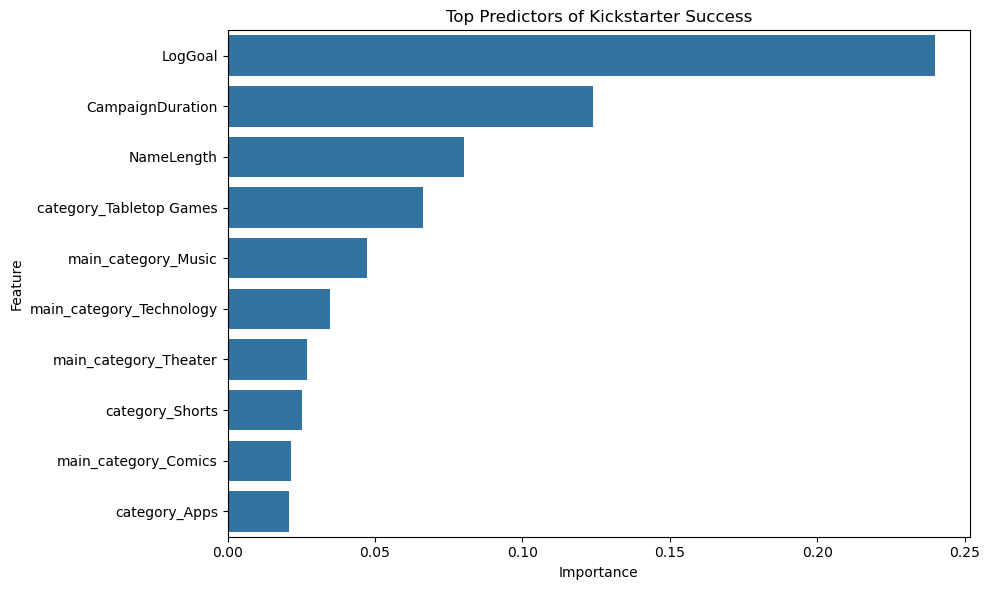

In [45]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top Predictors of Kickstarter Success")
plt.tight_layout()
plt.show()

## XGBoost Model

In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75     39544
           1       0.64      0.51      0.57     26791

    accuracy                           0.69     66335
   macro avg       0.67      0.66      0.66     66335
weighted avg       0.68      0.69      0.68     66335

ROC-AUC: 0.7466335208159628


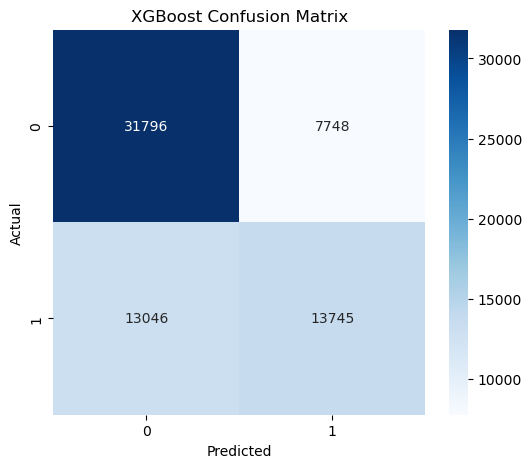

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

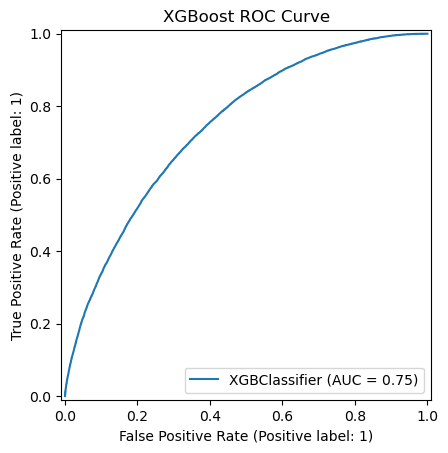

In [49]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.title("XGBoost ROC Curve")
plt.show()

In [48]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        0.725,
        0.725,
        0.747
    ]
})

model_results

,Model,ROC_AUC
0,Logistic Regression,0.725
1,Random Forest,0.725
2,XGBoost,0.747


## Executive Summary

This project analyzed 331,675 Kickstarter crowdfunding campaigns to identify factors associated with successful fundraising outcomes.

After removing post-launch data leakage variables, performing statistical hypothesis testing, and engineering campaign-level features, Logistic Regression, Random Forest, and XGBoost models were developed to predict campaign success prior to launch.

The final XGBoost model achieved a ROC-AUC of 0.747, demonstrating moderate predictive capability using only information available before campaign launch.

Key findings included:

• Funding goal size was the strongest predictor of campaign success.

• Campaign duration significantly influenced outcomes, with shorter campaigns achieving substantially higher success rates.

• Project category demonstrated a statistically significant relationship with campaign performance.

• Campaign title characteristics emerged as an important predictor, suggesting that communication and campaign presentation influence crowdfunding outcomes.

These findings indicate that campaign design decisions made before launch can meaningfully impact fundraising success and provide actionable guidance for crowdfunding creators seeking to improve campaign performance.
